<a href="https://colab.research.google.com/github/iiiyahiya111/Plant-Disease-Detection-ResNet50-PCA-SVM/blob/main/r_hybrid__.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL Phases

**Features Extraction by ResNet50**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install and configure Kaggle API
!pip install -q kaggle
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader
from tqdm import tqdm

# Download PlantVillage dataset
print("Downloading dataset...")
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

print("Extracting files...")
!unzip -q /content/plantvillage-dataset.zip -d /content/PlantVillage

# Dataset and feature paths
DATASET_PATH = "/content/PlantVillage/plantvillage dataset/color"
FEATURE_PATH = "/content/drive/MyDrive/PlantDisease_Project/features"

os.makedirs(FEATURE_PATH, exist_ok=True)

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load images
dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

print(f"Images: {len(dataset)}")
print(f"Classes: {len(dataset.classes)}")

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

# Load pretrained ResNet50
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Remove the final classification layer
model = nn.Sequential(*list(model.children())[:-1])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.eval()

# Extract deep features
def extract_features(model, dataloader, device):
    features = []
    labels = []

    with torch.no_grad():
        for images, target in tqdm(dataloader, desc="Processing"):

            images = images.to(device)

            output = model(images)
            output = torch.flatten(output, start_dim=1)

            features.append(output.cpu())
            labels.append(target)

    features = torch.cat(features).numpy()
    labels = torch.cat(labels).numpy()

    return features, labels


X, y = extract_features(model, loader, device)

# Save extracted features
np.save(os.path.join(FEATURE_PATH, "X_full.npy"), X)
np.save(os.path.join(FEATURE_PATH, "y_full.npy"), y)

print("Feature extraction completed.")
print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [01:40<00:00, 21.9MB/s]

Extracting files...
Images: 54305
Classes: 38
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]
Processing: 100%|██████████| 425/425 [03:19<00:00,  2.13it/s]


Feature extraction completed.
Feature shape: (54305, 2048)
Label shape: (54305,)


# ML Phase

**Fit with SVM**

In [ ]:
import os
import joblib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# Paths
FEATURE_PATH = "/content/drive/MyDrive/PlantDisease_Project/features"
MODEL_PATH = "/content/drive/MyDrive/PlantDisease_Project/models"

os.makedirs(MODEL_PATH, exist_ok=True)

# Load extracted features
X = np.load(os.path.join(FEATURE_PATH, "X_full.npy"))
y = np.load(os.path.join(FEATURE_PATH, "y_full.npy"))

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Reduce feature dimensions using PCA
print("\nApplying PCA...")

pca = PCA(n_components=256, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("PCA completed.")
print("Training feature shape:", X_train_pca.shape)

# Train the SVM classifier
print("\nTraining Linear SVM...")

classifier = SVC(
    kernel="linear",
    C=1.0,
    random_state=42
)

classifier.fit(X_train_pca, y_train)

print("Training finished.")

# Save the trained models
joblib.dump(pca, os.path.join(MODEL_PATH, "pca_full.pkl"))
joblib.dump(classifier, os.path.join(MODEL_PATH, "svm_full.pkl"))

print("Models have been saved successfully.")

Training samples: 43444
Testing samples: 10861

Applying PCA...
PCA completed.
Training feature shape: (43444, 256)

Training Linear SVM...
Training finished.
Models have been saved successfully.


**Evaluation & Visualization**

Running 5-Fold Cross-Validation...

Cross-Validation Results
Fold Accuracies: [0.97479572 0.97203361 0.97203361 0.97571642 0.9736418 ]
Mean Accuracy: 0.9736
Standard Deviation: 0.0029

Final Test Results
Accuracy : 0.9735
Precision: 0.9737
Recall   : 0.9735
F1-score : 0.9735

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.98      0.99       126
                                 Apple___Black_rot       0.98      0.98      0.98       124
                          Apple___Cedar_apple_rust       0.98      0.96      0.97        55
                                   Apple___healthy       0.99      0.99      0.99       329
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy     

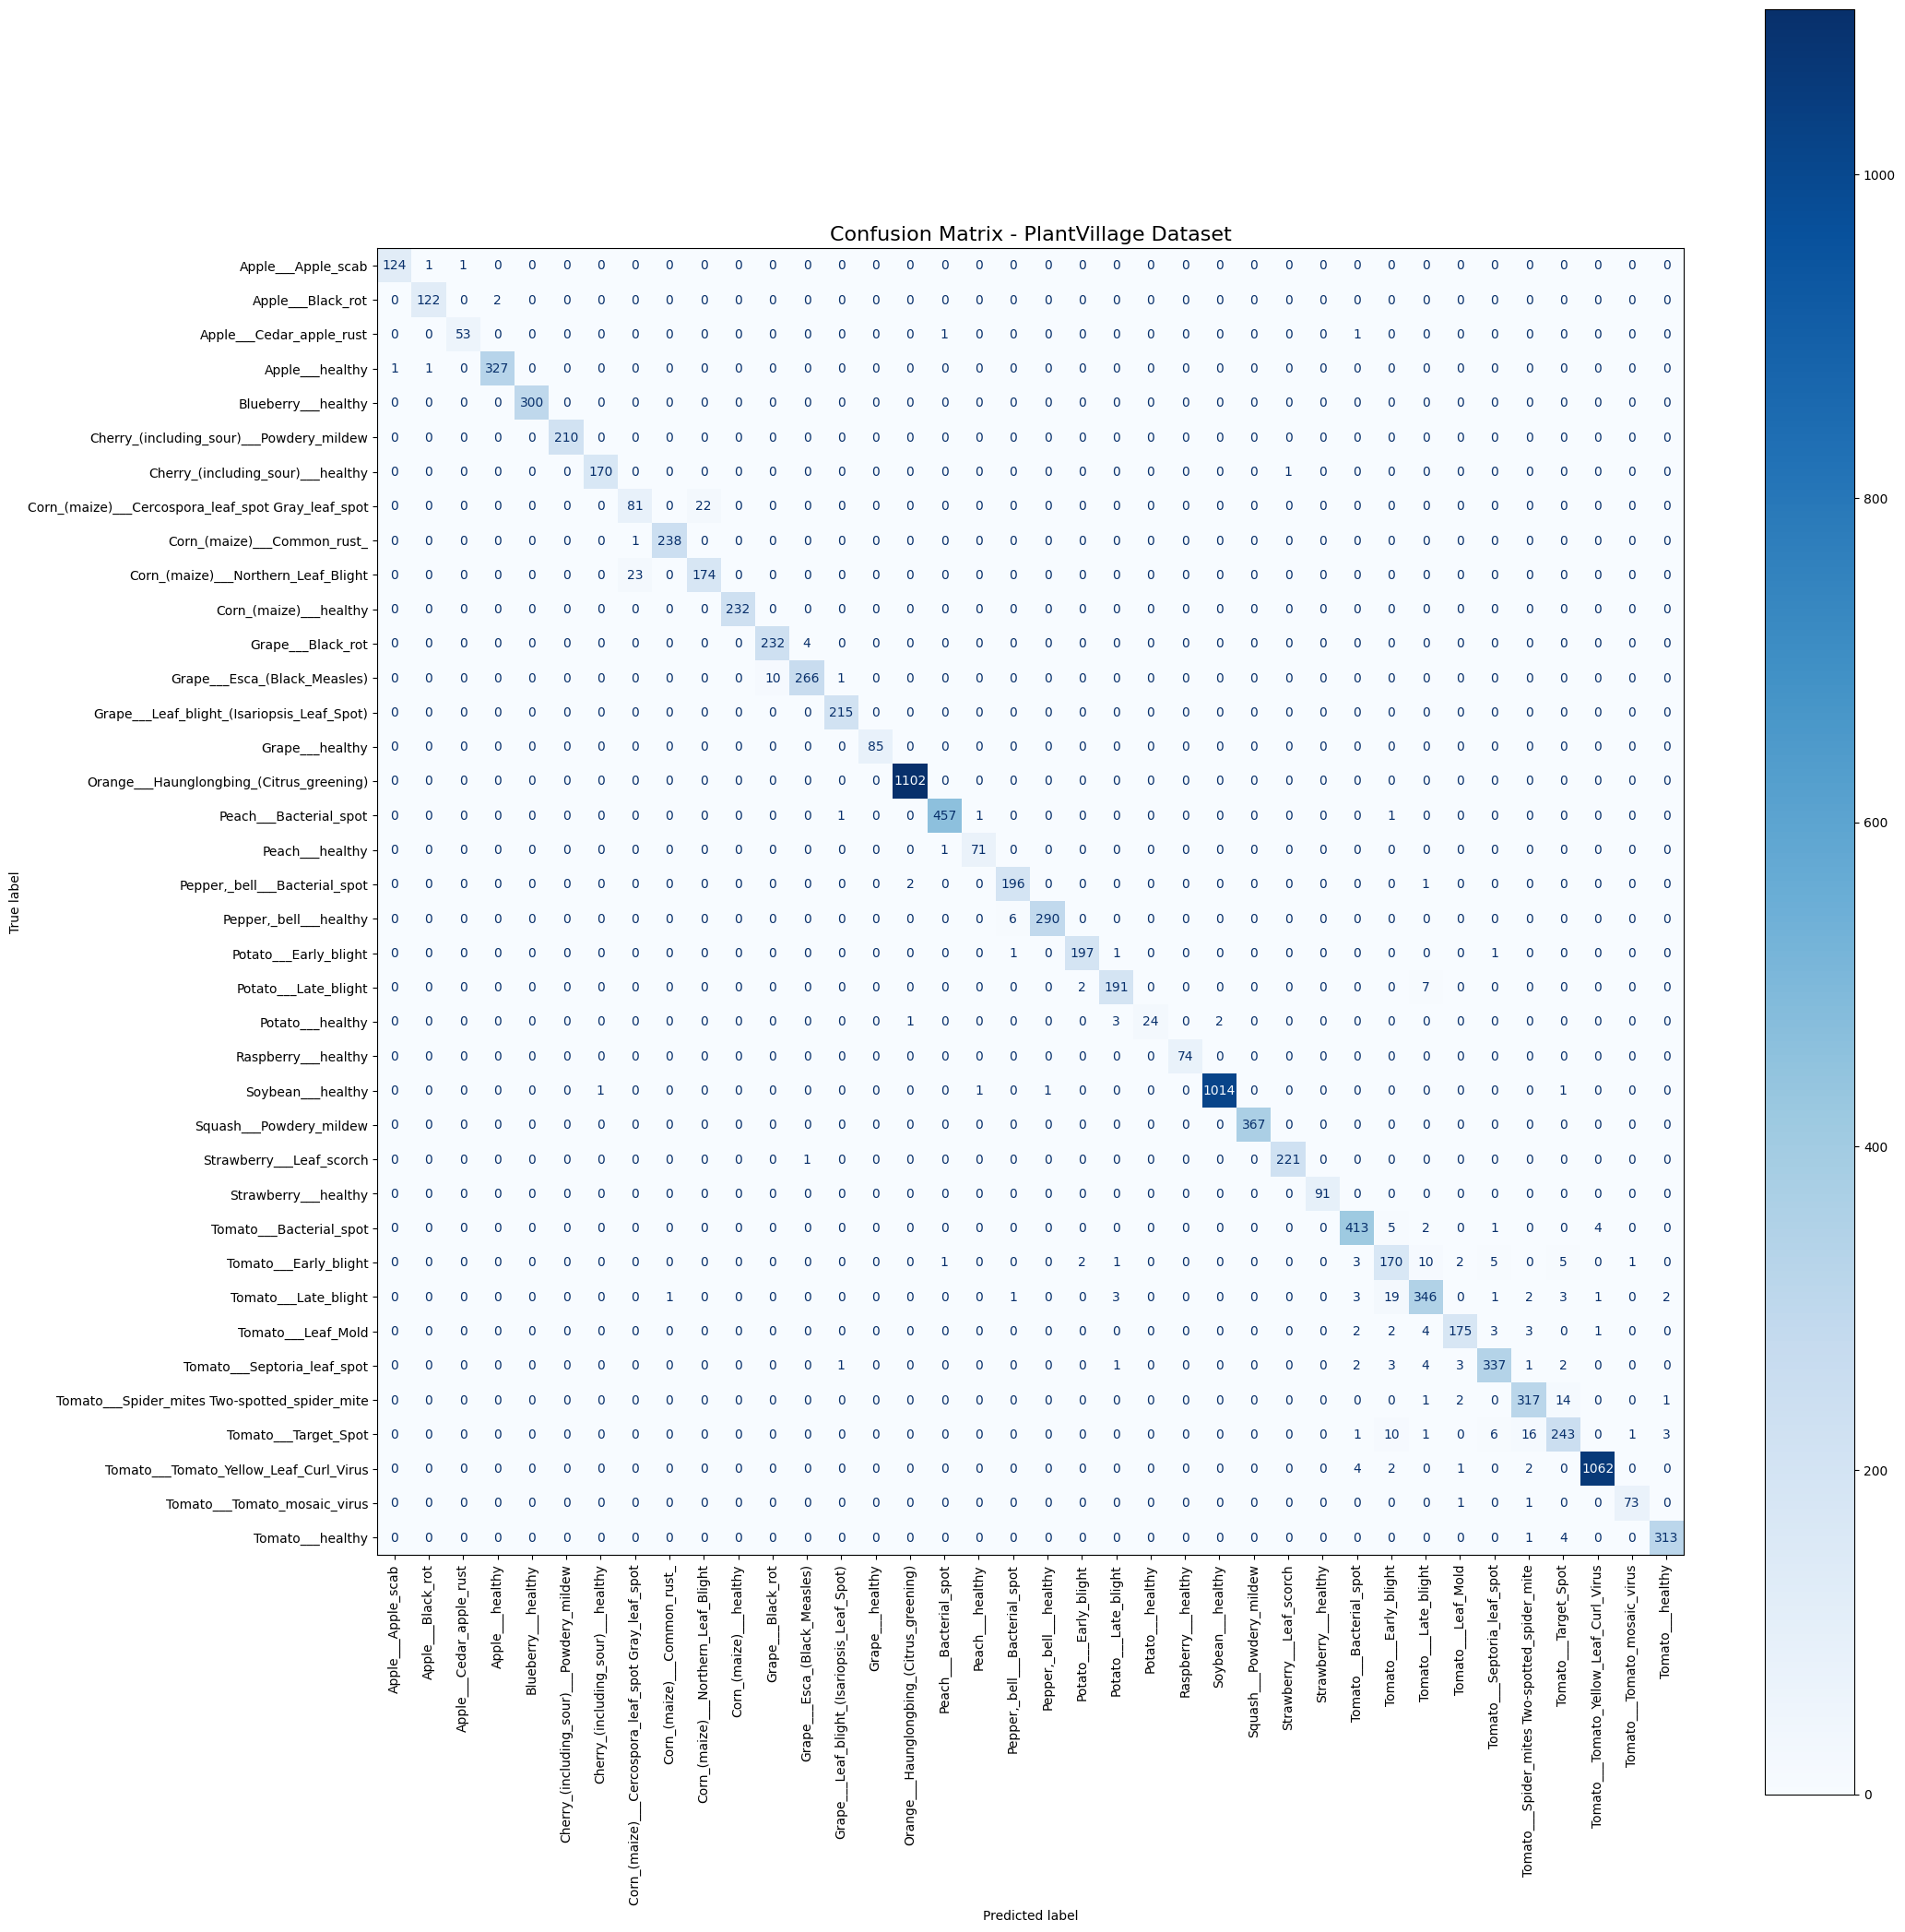

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Run 5-fold cross-validation on the training data
print("Running 5-Fold Cross-Validation...")

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    classifier,
    X_train_pca,
    y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("\nCross-Validation Results")
print(f"Fold Accuracies: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std() * 2:.4f}\n")

# Make predictions on the test set
y_pred = classifier.predict(X_test_pca)

# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Final Test Results")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}\n")

# Show the classification report
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=dataset.classes
))

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(22, 22))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

display.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation="vertical"
)

plt.title("Confusion Matrix - PlantVillage Dataset", fontsize=16)
plt.tight_layout()
plt.show()